In [14]:
import os,sys
from importlib import reload
import time,copy
import struct
import math
import gc

import joblib
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt


%matplotlib inline
%config InlineBackend.figure_format='retina'

import pyvisa
import helper_visa
import helper_basic as hp
import helper_fft
import user_io.IO_siglent as uio
reload(uio)

<module 'user_io.IO_siglent' from '/mnt/c/Users/Tom/OneDrive/Documents/JupyterNotebooks/CDMS/VisaScope/SpecExplorer/user_io/IO_siglent.py'>

In [41]:
addr = "TCPIP::192.168.1.233::INSTR"

rm = pyvisa.ResourceManager()
rm.list_resources()
device = rm.open_resource(addr)
print(scope.query('*IDN?'))

siglent = uio.siglent_sds(device)

Siglent Technologies,SDS824X HD,SDS08A0Q809301,3.8.12.1.1.6.2

Siglent Technologies,SDS824X HD,SDS08A0Q809301,3.8.12.1.1.6.2



In [31]:
data_freq, data_real, data_imag = siglent.get_fft(plot=False)

FFT length: 1048576


Text(0.5, 0, 'Frequency [Hz]')

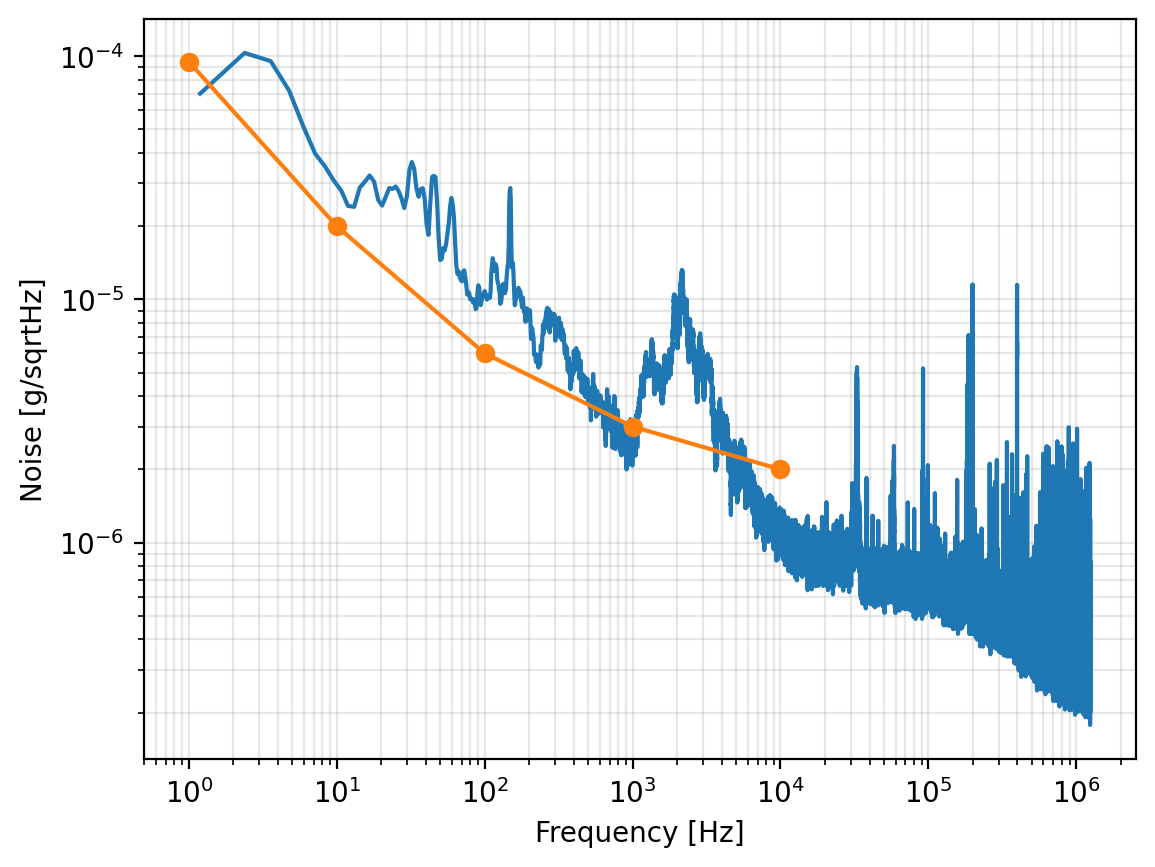

In [42]:
ref_x = [1,10,100,1000,10e3]
ref_y = np.array([95,20,6,3,2])*1e-6

psd =  data_real/10/np.sqrt(data_freq[1]-data_freq[0])
plt.plot(data_freq,psd/0.1)
plt.plot(ref_x, ref_y, marker="o")
plt.yscale("log")
plt.grid(which="both", alpha=0.3)
plt.xscale("log")
# plt.ylabel("Noise [V/sqrtHz]")
plt.ylabel("Noise [g/sqrtHz]")
plt.xlabel("Frequency [Hz]")
# joblib.dump({"Freq": data_freq, "PSD": psd}, "data/pcb356a32_walking_.joblib")